# TUGAS BESAR — ALGORITMA NAIVE BAYES
## Klasifikasi Data Kategorikal — Dataset `drug200`

**Mata Kuliah:** Kecerdasan Buatan
**Algoritma:** Naive Bayes Classifier (data kategorikal)
**Dataset:** `drug200_NAIVE_BAYES_.xlsx` (200 baris, 4 fitur kategorikal + 1 label kelas)

Struktur notebook ini mengikuti struktur laporan pada dokumen *Deskripsi Tugas Besar*:
1. **Pendahuluan** — penjelasan umum algoritma (tanpa kasus)
2. **Simulasi Kasus** — perhitungan manual langkah-demi-langkah menggunakan seluruh data & fitur
3. **Implementasi** — kode program dari nol (*from scratch*, tanpa library ML) mengikuti setiap langkah algoritma
4. **Evaluasi** — pengujian akurasi model
5. **Daftar Pustaka**


## 1. PENDAHULUAN

### 1.1 Latar Belakang Ketidakpastian (Uncertainty)
Dalam banyak persoalan kecerdasan buatan, lingkungan bersifat **tidak pasti (uncertain)** — informasi yang tersedia
tidak lengkap, ambigu, atau tidak dapat diobservasi sepenuhnya (Russell & Norvig, dalam materi *Uncertainty*, LMS).
Pendekatan logika murni (proposisional/predikat) menjadi lemah karena aturan yang dibuat cenderung terlalu spesifik
atau terlalu general untuk menggambarkan dunia nyata. Oleh karena itu dibutuhkan pendekatan berbasis **probabilitas**
untuk menalar dalam kondisi tidak pasti, salah satunya adalah pendekatan **Bayesian**.

### 1.2 Teorema Bayes
Teorema Bayes menyatakan hubungan antara *probabilitas bersyarat* dua kejadian A dan B:

$$P(A \mid B) = \frac{P(B \mid A)\, P(A)}{P(B)}$$

Dalam konteks klasifikasi, **A** adalah kelas target (*Y*) dan **B** adalah gabungan fitur/atribut yang diamati (*X*).
Sehingga:

$$P(Y \mid X_1, X_2, \dots, X_n) = \frac{P(X_1, X_2, \dots, X_n \mid Y)\, P(Y)}{P(X_1, X_2, \dots, X_n)}$$

Pendekatan ini banyak digunakan untuk penalaran **abduktif**: dari akibat (gejala/fitur yang teramati) menuju sebab
(kelas/diagnosis), misalnya diagnosis penyakit berdasarkan gejala.

### 1.3 Asumsi "Naive"
Menghitung $P(X_1,\dots,X_n \mid Y)$ secara langsung sangat mahal karena harus memodelkan seluruh kombinasi antar fitur.
Naive Bayes menyederhanakan ini dengan **asumsi independensi bersyarat** antar fitur terhadap kelasnya — setiap fitur
dianggap tidak saling memengaruhi satu sama lain, sehingga:

$$P(X_1, X_2, \dots, X_n \mid Y) = \prod_{i=1}^{n} P(X_i \mid Y)$$

Karena penyebut $P(X)$ sama untuk semua kelas yang dibandingkan, maka rumus klasifikasi Naive Bayes menjadi:

$$\hat{Y} = \arg\max_{Y} \; P(Y) \prod_{i=1}^{n} P(X_i \mid Y)$$

Asumsi ini secara teknis jarang benar-benar terpenuhi di data nyata (fitur sering berkorelasi), namun secara empiris
metode ini tetap memberi hasil klasifikasi yang baik dan efisien secara komputasi, sehingga disebut "naif" (*naive*).

### 1.4 Naive Bayes untuk Data Kategorikal
Ketika seluruh fitur bersifat **kategorikal/diskrit** (bukan numerik kontinu), $P(X_i \mid Y)$ dihitung langsung
sebagai proporsi frekuensi menggunakan **tabel kontingensi**, bukan fungsi kepadatan Gaussian. Untuk menghindari
probabilitas nol ketika suatu kombinasi nilai tidak muncul pada data latih, digunakan **Laplace (additive) smoothing**:

$$P(X_i = x \mid Y = y) = \frac{\text{jumlah}(X_i{=}x, Y{=}y) + 1}{\text{jumlah}(Y{=}y) + k_i}$$

dengan $k_i$ = banyaknya nilai unik yang mungkin untuk fitur $X_i$.

### 1.5 Langkah-Langkah Algoritma Naive Bayes (Data Kategorikal)
Secara umum (tanpa kasus spesifik), langkah algoritmanya adalah:

1. **Pengumpulan & pembagian data** — siapkan data latih (training) yang berisi pasangan fitur kategorikal dan label
   kelasnya.
2. **Hitung Prior** — hitung $P(Y=y)$ untuk setiap kelas $y$, yaitu proporsi jumlah data pada kelas tersebut terhadap
   seluruh data latih.
3. **Bangun Tabel Kontingensi (Likelihood)** — untuk setiap fitur, hitung frekuensi kemunculan tiap nilai fitur pada
   masing-masing kelas, lalu ubah menjadi peluang bersyarat $P(X_i \mid Y)$ (dengan Laplace smoothing bila perlu).
4. **Hitung Posterior untuk data baru (query)** — untuk instansi baru dengan fitur $X_1,\dots,X_n$, hitung skor tiap
   kelas: $\text{skor}(y) = P(y)\prod_i P(X_i \mid y)$.
5. **Normalisasi (opsional)** — bagi setiap skor kelas dengan jumlah seluruh skor agar berbentuk peluang $\in[0,1]$.
6. **Keputusan (klasifikasi)** — pilih kelas dengan skor/posterior terbesar sebagai hasil prediksi:
   $\hat{Y} = \arg\max_y \text{skor}(y)$.
7. **Evaluasi** — bandingkan hasil prediksi dengan label sebenarnya pada data uji untuk menghitung akurasi model.

Referensi terkait konsep dan penerapan Naive Bayes pada data kategorikal dapat dilihat pada Daftar Pustaka
(Hardianti, 2018; Indraja & Annapurani, 2018; JATI-ITN, 2020, 2023).


## 2. Dataset

Dataset yang digunakan adalah **`drug200_NAIVE_BAYES_.xlsx`**, berisi **200 baris data pasien** dengan **4 fitur
kategorikal** dan **1 label kelas** (jenis obat yang direkomendasikan):

| Fitur | Tipe | Nilai yang mungkin |
|---|---|---|
| `Age` | Kategorikal | YOUNG, ADULT, OLD |
| `BP` (tekanan darah) | Kategorikal | HIGH, NORMAL, LOW |
| `Cholesterol` | Kategorikal | HIGH, NORMAL |
| `Na_to_K` (rasio Na/K, dikategorikan) | Kategorikal | HIGH, NORMAL, LOW |
| `ClassDrug` (label) | Kategorikal (target) | DrugY, drugX, drugA, drugB, drugC |

Karena **seluruh fitur bertipe kategorikal**, algoritma yang paling sesuai adalah **Naive Bayes kategorikal**
(menggunakan tabel kontingensi frekuensi), bukan Gaussian Naive Bayes (yang dipakai untuk fitur numerik kontinu).
Ini sesuai dengan materi *Naive Bayes data kategorial* pada slide perkuliahan.


In [27]:
# Membaca dataset (hanya membaca file -> BUKAN bagian dari algoritma Naive Bayes)
import openpyxl

wb = openpyxl.load_workbook('./data/drug200(NAIVE BAYES).xlsx', data_only=True)
ws = wb.active

header = [c.value for c in next(ws.iter_rows(min_row=1, max_row=1))]
data = []
for row in ws.iter_rows(min_row=2, values_only=True):
    data.append(dict(zip(header, row)))

print('Kolom     :', header)
print('Jumlah data:', len(data))
print('Contoh 5 baris pertama:')
for d in data[:5]:
    print(d)


Kolom     : ['Age', 'BP', 'Cholesterol', 'Na_to_K', 'ClassDrug']
Jumlah data: 200
Contoh 5 baris pertama:
{'Age': 'YOUNG', 'BP': 'HIGH', 'Cholesterol': 'HIGH', 'Na_to_K': 'NORMAL', 'ClassDrug': 'drugA'}
{'Age': 'YOUNG', 'BP': 'HIGH', 'Cholesterol': 'HIGH', 'Na_to_K': 'NORMAL', 'ClassDrug': 'drugA'}
{'Age': 'YOUNG', 'BP': 'HIGH', 'Cholesterol': 'HIGH', 'Na_to_K': 'LOW', 'ClassDrug': 'drugA'}
{'Age': 'YOUNG', 'BP': 'HIGH', 'Cholesterol': 'NORMAL', 'Na_to_K': 'LOW', 'ClassDrug': 'drugA'}
{'Age': 'ADULT', 'BP': 'HIGH', 'Cholesterol': 'NORMAL', 'Na_to_K': 'NORMAL', 'ClassDrug': 'drugA'}


### 2.1 Visualisasi Data (Eksplorasi Awal)

Sebelum masuk ke perhitungan Naive Bayes, berikut visualisasi sederhana menggunakan **seaborn** agar data lebih
mudah dipahami — khususnya untuk pembaca awam yang belum familiar dengan angka probabilitas.


C:\Users\Rizkya Gusnaldy\AppData\Local\Temp\ipykernel_12144\2027485332.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='ClassDrug', order=urutan_kelas, palette='viridis')


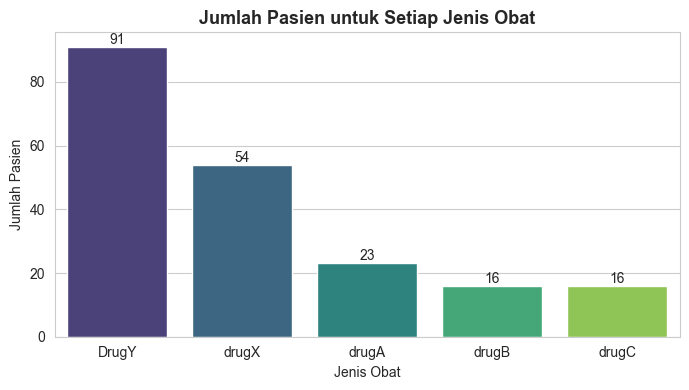

In [28]:
# Visualisasi 1: Berapa banyak pasien di tiap jenis obat? (grafik batang paling mudah dibaca orang awam)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
df = pd.DataFrame(data)  # hanya untuk keperluan visualisasi, TIDAK dipakai untuk perhitungan Naive Bayes

plt.figure(figsize=(7, 4))
urutan_kelas = df['ClassDrug'].value_counts().index
ax = sns.countplot(data=df, x='ClassDrug', order=urutan_kelas, palette='viridis')
ax.set_title('Jumlah Pasien untuk Setiap Jenis Obat', fontsize=13, fontweight='bold')
ax.set_xlabel('Jenis Obat')
ax.set_ylabel('Jumlah Pasien')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


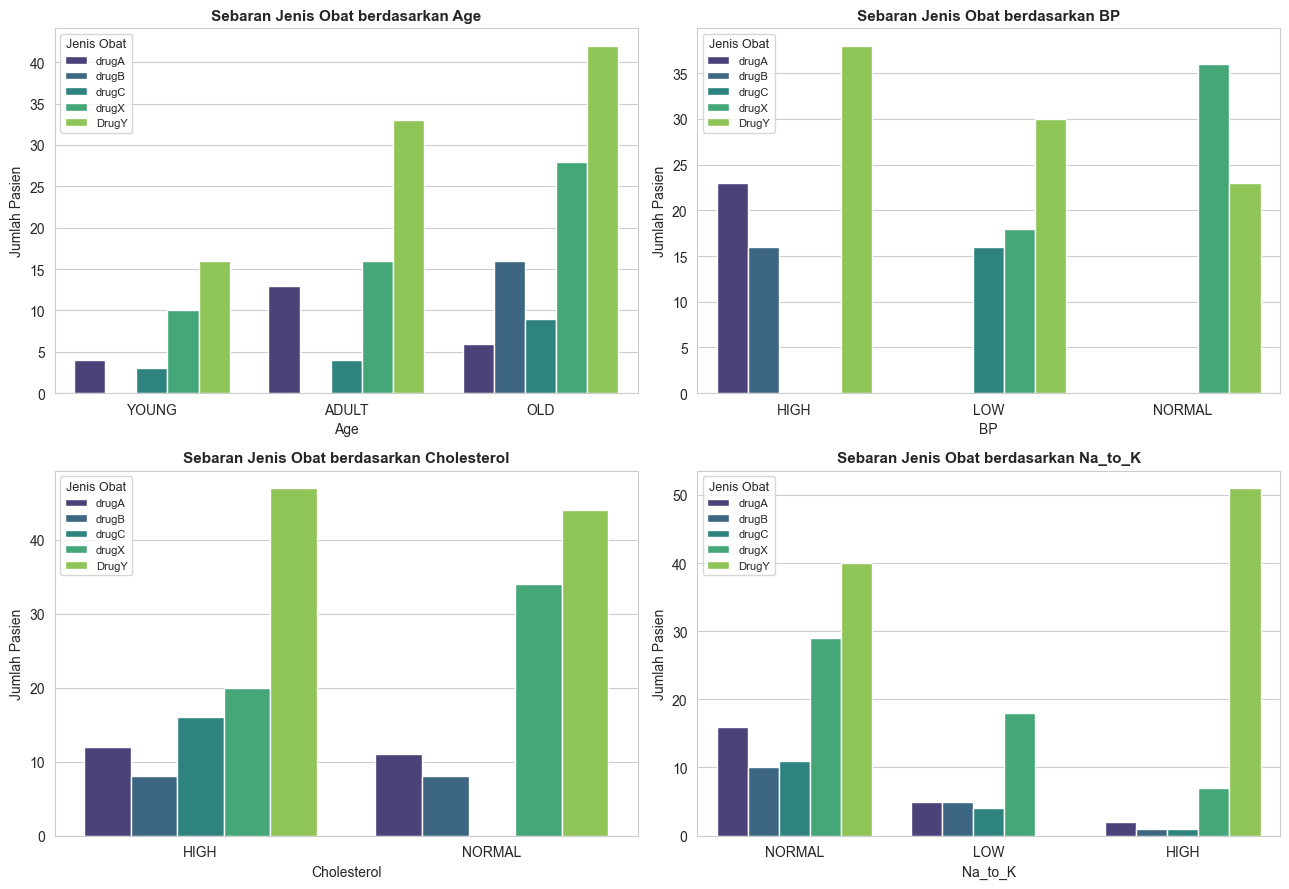

In [29]:
# Visualisasi 2: Bagaimana sebaran tiap fitur (Age, BP, Cholesterol, Na_to_K) pada masing-masing jenis obat?
# Menjawab pertanyaan awam: "obat apa yang biasanya diberikan untuk kondisi pasien seperti apa?"
fitur_viz = ['Age', 'BP', 'Cholesterol', 'Na_to_K']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, f in enumerate(fitur_viz):
    sns.countplot(data=df, x=f, hue='ClassDrug', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Sebaran Jenis Obat berdasarkan {f}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(f)
    axes[i].set_ylabel('Jumlah Pasien')
    axes[i].legend(title='Jenis Obat', fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()


**Cara membaca grafik di atas (untuk orang awam):** setiap warna batang mewakili satu jenis obat. Semakin
tinggi batang suatu warna pada kategori tertentu (misalnya `Na_to_K = HIGH`), artinya semakin sering pasien dengan
kondisi tersebut diberi obat itu. Contohnya, hampir semua pasien dengan `Na_to_K = HIGH` mendapat **DrugY** — pola
inilah yang sebenarnya "dipelajari" oleh algoritma Naive Bayes lewat perhitungan peluang (likelihood).


## 3. SIMULASI KASUS (Perhitungan Manual)

Pada bagian ini, proses Naive Bayes dilakukan **secara manual, langkah demi langkah**, menggunakan **seluruh 200
baris data dan seluruh 4 fitur** dataset `drug200` (tidak disampel), mengikuti pola contoh pada materi (tabel
kontingensi "Layak direkomendasikan" pada slide Naive Bayes).

Kelas target: `ClassDrug` = {DrugY, drugX, drugA, drugB, drugC}
Fitur: `Age`, `BP`, `Cholesterol`, `Na_to_K`

### Langkah 1 — Hitung Prior P(Kelas)
Prior dihitung dari proporsi jumlah masing-masing kelas obat terhadap total 200 data.


In [30]:
# Langkah 1: PRIOR P(kelas) -- dihitung manual dengan looping, tanpa fungsi statistik siap pakai
from collections import OrderedDict

def hitung_prior(data, target_col):
    total = len(data)
    jumlah_kelas = OrderedDict()
    for row in data:
        y = row[target_col]
        jumlah_kelas[y] = jumlah_kelas.get(y, 0) + 1
    prior = OrderedDict()
    for y, n in jumlah_kelas.items():
        prior[y] = n / total
    return jumlah_kelas, prior

jumlah_kelas, prior = hitung_prior(data, 'ClassDrug')

print(f"{'Kelas':<8}{'Jumlah':<10}{'Prior P(Y)':<12}")
for y in jumlah_kelas:
    print(f"{y:<8}{jumlah_kelas[y]:<10}{prior[y]:<12.4f}")


Kelas   Jumlah    Prior P(Y)  
drugA   23        0.1150      
drugB   16        0.0800      
drugC   16        0.0800      
drugX   54        0.2700      
DrugY   91        0.4550      


**Visualisasi Prior** — semakin tinggi batang, semakin besar peluang awal (sebelum melihat fitur pasien) obat tersebut yang direkomendasikan:

C:\Users\Rizkya Gusnaldy\AppData\Local\Temp\ipykernel_12144\467243144.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=kelas_urut, y=nilai_prior, palette='viridis')


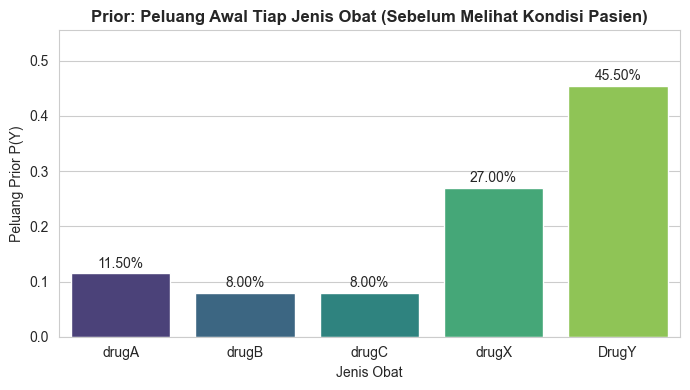

In [31]:
plt.figure(figsize=(7, 4))
kelas_urut = list(prior.keys())
nilai_prior = [prior[k] for k in kelas_urut]

ax = sns.barplot(x=kelas_urut, y=nilai_prior, palette='viridis')
ax.set_title('Prior: Peluang Awal Tiap Jenis Obat (Sebelum Melihat Kondisi Pasien)', fontsize=12, fontweight='bold')
ax.set_xlabel('Jenis Obat')
ax.set_ylabel('Peluang Prior P(Y)')
ax.set_ylim(0, max(nilai_prior) + 0.1)
for i, v in enumerate(nilai_prior):
    ax.text(i, v + 0.01, f'{v:.2%}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### Langkah 2 — Bangun Tabel Kontingensi & Hitung Likelihood P(Fitur | Kelas)

Untuk tiap fitur, dibuat tabel kontingensi: baris = kelas, kolom = nilai fitur, isi = jumlah kemunculan.
Likelihood dihitung dengan **Laplace smoothing** agar tidak ada probabilitas nol:

$$P(X_i{=}x \mid Y{=}y) = \dfrac{\text{count}(X_i{=}x,\, Y{=}y) + 1}{\text{count}(Y{=}y) + k_i}$$


In [32]:
# Langkah 2: Tabel kontingensi + likelihood (Laplace smoothing), murni looping/dict manual

fitur_list = ['Age', 'BP', 'Cholesterol', 'Na_to_K']

def nilai_unik(data, kolom):
    hasil = []
    for row in data:
        v = row[kolom]
        if v not in hasil:
            hasil.append(v)
    return hasil

def tabel_kontingensi(data, kolom, target_col, kelas_list):
    nilai_list = nilai_unik(data, kolom)
    tabel = OrderedDict((v, OrderedDict((y, 0) for y in kelas_list)) for v in nilai_list)
    for row in data:
        tabel[row[kolom]][row[target_col]] += 1
    return tabel, nilai_list

kelas_list = list(jumlah_kelas.keys())
kontingensi = {}
nilai_fitur = {}
for f in fitur_list:
    tabel, nilai_list = tabel_kontingensi(data, f, 'ClassDrug', kelas_list)
    kontingensi[f] = tabel
    nilai_fitur[f] = nilai_list
    print(f"\nTabel kontingensi fitur '{f}':")
    print(f"{'Nilai':<10}" + ''.join(f"{y:<8}" for y in kelas_list))
    for v in nilai_list:
        print(f"{v:<10}" + ''.join(f"{tabel[v][y]:<8}" for y in kelas_list))



Tabel kontingensi fitur 'Age':
Nilai     drugA   drugB   drugC   drugX   DrugY   
YOUNG     4       0       3       10      16      
ADULT     13      0       4       16      33      
OLD       6       16      9       28      42      

Tabel kontingensi fitur 'BP':
Nilai     drugA   drugB   drugC   drugX   DrugY   
HIGH      23      16      0       0       38      
LOW       0       0       16      18      30      
NORMAL    0       0       0       36      23      

Tabel kontingensi fitur 'Cholesterol':
Nilai     drugA   drugB   drugC   drugX   DrugY   
HIGH      12      8       16      20      47      
NORMAL    11      8       0       34      44      

Tabel kontingensi fitur 'Na_to_K':
Nilai     drugA   drugB   drugC   drugX   DrugY   
NORMAL    16      10      11      29      40      
LOW       5       5       4       18      0       
HIGH      2       1       1       7       51      


In [33]:
# Likelihood P(fitur=nilai | kelas) dengan Laplace smoothing
likelihood = {}
for f in fitur_list:
    k_i = len(nilai_fitur[f])
    likelihood[f] = OrderedDict()
    for v in nilai_fitur[f]:
        likelihood[f][v] = OrderedDict()
        for y in kelas_list:
            likelihood[f][v][y] = (kontingensi[f][v][y] + 1) / (jumlah_kelas[y] + k_i)

# Tampilkan salah satu contoh tabel likelihood: fitur Na_to_K
print("Likelihood P(Na_to_K = v | Kelas):")
print(f"{'Nilai':<10}" + ''.join(f"{y:<10}" for y in kelas_list))
for v in nilai_fitur['Na_to_K']:
    print(f"{v:<10}" + ''.join(f"{likelihood['Na_to_K'][v][y]:<10.4f}" for y in kelas_list))


Likelihood P(Na_to_K = v | Kelas):
Nilai     drugA     drugB     drugC     drugX     DrugY     
NORMAL    0.6538    0.5789    0.6316    0.5263    0.4362    
LOW       0.2308    0.3158    0.2632    0.3333    0.0106    
HIGH      0.1154    0.1053    0.1053    0.1404    0.5532    


### Langkah 3 — Contoh Kasus Uji (Query)

Karena tidak ada kasus terpisah yang disertakan bersama file dataset ini, simulasi berikut mengambil **satu baris
data asli** dari dataset sebagai contoh kasus uji (query), untuk menunjukkan proses perhitungan Naive Bayes secara
lengkap. *(Jika dosen/soal memberikan kasus khusus melalui link drive kelompok, gunakan nilai fitur dari kasus
tersebut sebagai pengganti `query` pada sel kode di bawah ini — struktur perhitungan tetap sama.)*


In [34]:
# Langkah 3: tentukan query (contoh: baris ke-10 pada data, label sebenarnya disembunyikan)
contoh = data[9]
query = {f: contoh[f] for f in fitur_list}
label_asli = contoh['ClassDrug']

print("Data fitur query :", query)
print("Label sebenarnya :", label_asli, "(hanya untuk verifikasi, tidak dipakai saat prediksi)")


Data fitur query : {'Age': 'ADULT', 'BP': 'HIGH', 'Cholesterol': 'NORMAL', 'Na_to_K': 'NORMAL'}
Label sebenarnya : drugA (hanya untuk verifikasi, tidak dipakai saat prediksi)


### Langkah 4 — Hitung Skor Posterior tiap Kelas

$$\text{skor}(y) = P(y) \times \prod_{i} P(X_i \mid y)$$


In [35]:
# Langkah 4: hitung skor posterior (belum dinormalisasi) untuk tiap kelas -- manual
def hitung_skor(query, prior, likelihood, kelas_list, fitur_list, nilai_fitur, jumlah_kelas):
    skor = OrderedDict()
    for y in kelas_list:
        s = prior[y]
        for f in fitur_list:
            v = query[f]
            if v in likelihood[f]:
                s *= likelihood[f][v][y]
            else:
                # nilai fitur belum pernah muncul di data latih -> Laplace smoothing generik
                k_i = len(nilai_fitur[f])
                s *= 1 / (jumlah_kelas[y] + k_i)
        skor[y] = s
    return skor

skor = hitung_skor(query, prior, likelihood, kelas_list, fitur_list, nilai_fitur, jumlah_kelas)

print(f"{'Kelas':<8}{'Skor (belum dinormalisasi)':<30}")
for y in kelas_list:
    print(f"{y:<8}{skor[y]:<30.10f}")


Kelas   Skor (belum dinormalisasi)    
drugA   0.0179393719                  
drugB   0.0010905380                  
drugC   0.0000388784                  
drugX   0.0004647179                  
DrugY   0.0144106902                  


### Langkah 5 — Normalisasi menjadi Peluang & Langkah 6 — Keputusan Klasifikasi

In [36]:
# Langkah 5: normalisasi & Langkah 6: ambil kelas dengan posterior terbesar
total_skor = sum(skor.values())
posterior = OrderedDict((y, skor[y] / total_skor) for y in kelas_list)

print(f"{'Kelas':<8}{'Posterior P(Y|X)':<20}")
for y in kelas_list:
    print(f"{y:<8}{posterior[y]:<20.4f}")

prediksi = max(posterior, key=posterior.get)
print(f"\n>> Prediksi kelas untuk query {query}: {prediksi}")
print(f">> Label sebenarnya (verifikasi)       : {label_asli}")
print(f">> Prediksi {'BENAR' if prediksi == label_asli else 'SALAH'}")


Kelas   Posterior P(Y|X)    
drugA   0.5285              
drugB   0.0321              
drugC   0.0011              
drugX   0.0137              
DrugY   0.4245              

>> Prediksi kelas untuk query {'Age': 'ADULT', 'BP': 'HIGH', 'Cholesterol': 'NORMAL', 'Na_to_K': 'NORMAL'}: drugA
>> Label sebenarnya (verifikasi)       : drugA
>> Prediksi BENAR


**Visualisasi Posterior** — grafik ini menunjukkan seberapa yakin model terhadap tiap kemungkinan obat untuk pasien pada contoh kasus di atas. Batang tertinggi = obat yang dipilih sebagai prediksi akhir:

C:\Users\Rizkya Gusnaldy\AppData\Local\Temp\ipykernel_12144\1464057892.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=kelas_urut2, y=nilai_post, palette=warna)


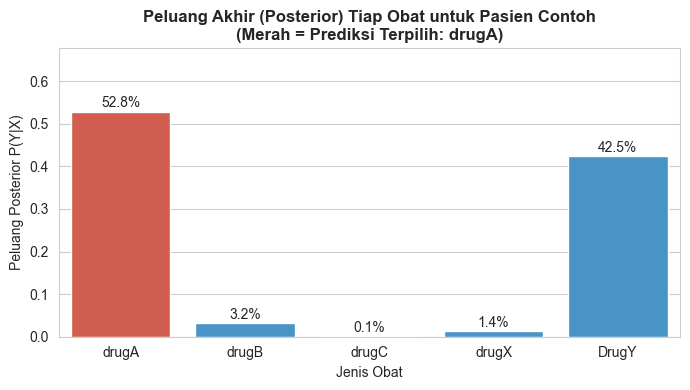

In [37]:
plt.figure(figsize=(7, 4))
kelas_urut2 = list(posterior.keys())
nilai_post = [posterior[k] for k in kelas_urut2]
warna = ['#e74c3c' if k == prediksi else '#3498db' for k in kelas_urut2]

ax = sns.barplot(x=kelas_urut2, y=nilai_post, palette=warna)
ax.set_title(f'Peluang Akhir (Posterior) Tiap Obat untuk Pasien Contoh\n(Merah = Prediksi Terpilih: {prediksi})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Jenis Obat')
ax.set_ylabel('Peluang Posterior P(Y|X)')
ax.set_ylim(0, max(nilai_post) + 0.15)
for i, v in enumerate(nilai_post):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


Simulasi manual di atas menunjukkan seluruh alur algoritma Naive Bayes kategorikal: mulai dari prior, tabel kontingensi, likelihood dengan Laplace smoothing, skor posterior, normalisasi, hingga pengambilan keputusan kelas. Bagian berikut membungkus proses yang sama ke dalam kode program (implementasi) yang dapat dipakai untuk memprediksi data mana pun, termasuk untuk pengujian akurasi terhadap keseluruhan dataset.

## 4. IMPLEMENTASI (From Scratch — Tanpa Library Machine Learning)

Implementasi berikut membangun ulang setiap langkah algoritma (Langkah 1–6 pada bagian Pendahuluan) sebagai
**fungsi Python murni**, tanpa memakai library klasifikasi (`sklearn`, dsb). Library yang digunakan hanya untuk
membaca file Excel (`openpyxl`) dan fungsi utilitas dasar (`random.shuffle` untuk pembagian data).

> **Catatan untuk laporan:** setiap langkah di bawah wajib disertai *screenshot* kode + output pada laporan Word
> sesuai instruksi Deskripsi Tugas Besar.

### Langkah A — Pembagian Data (Train / Test Split manual)


In [38]:
import random

def train_test_split_manual(data, rasio_test=0.2, seed=42):
    data_copy = data[:]
    random.seed(seed)
    random.shuffle(data_copy)
    n_test = int(len(data_copy) * rasio_test)
    data_test = data_copy[:n_test]
    data_train = data_copy[n_test:]
    return data_train, data_test

data_train, data_test = train_test_split_manual(data, rasio_test=0.2, seed=42)
print('Jumlah data latih :', len(data_train))
print('Jumlah data uji    :', len(data_test))


Jumlah data latih : 160
Jumlah data uji    : 40


### Langkah B — Fungsi Training (Prior + Tabel Kontingensi + Likelihood)

In [39]:
def naive_bayes_train(data_train, fitur_list, target_col):
    # Langkah 1: prior
    jumlah_kelas = OrderedDict()
    for row in data_train:
        y = row[target_col]
        jumlah_kelas[y] = jumlah_kelas.get(y, 0) + 1
    total = len(data_train)
    kelas_list = list(jumlah_kelas.keys())
    prior = OrderedDict((y, jumlah_kelas[y] / total) for y in kelas_list)

    # Langkah 2: nilai unik tiap fitur (dari data latih)
    nilai_fitur = {}
    for f in fitur_list:
        vals = []
        for row in data_train:
            if row[f] not in vals:
                vals.append(row[f])
        nilai_fitur[f] = vals

    # Langkah 2 (lanjutan): tabel kontingensi -> likelihood dgn Laplace smoothing
    likelihood = {}
    for f in fitur_list:
        tabel = OrderedDict((v, OrderedDict((y, 0) for y in kelas_list)) for v in nilai_fitur[f])
        for row in data_train:
            tabel[row[f]][row[target_col]] += 1
        k_i = len(nilai_fitur[f])
        likelihood[f] = OrderedDict()
        for v in nilai_fitur[f]:
            likelihood[f][v] = OrderedDict()
            for y in kelas_list:
                likelihood[f][v][y] = (tabel[v][y] + 1) / (jumlah_kelas[y] + k_i)

    model = {
        'kelas_list': kelas_list,
        'jumlah_kelas': jumlah_kelas,
        'prior': prior,
        'nilai_fitur': nilai_fitur,
        'likelihood': likelihood,
        'fitur_list': fitur_list,
    }
    return model

model = naive_bayes_train(data_train, fitur_list, 'ClassDrug')
print('Prior hasil training:')
for y in model['kelas_list']:
    print(f"  P({y}) = {model['prior'][y]:.4f}")


Prior hasil training:
  P(DrugY) = 0.4437
  P(drugX) = 0.3000
  P(drugA) = 0.1062
  P(drugC) = 0.0750
  P(drugB) = 0.0750


### Langkah C — Fungsi Prediksi (Posterior + Argmax)

In [40]:
def naive_bayes_predict(model, instance, return_proba=False):
    prior = model['prior']
    likelihood = model['likelihood']
    kelas_list = model['kelas_list']
    jumlah_kelas = model['jumlah_kelas']
    nilai_fitur = model['nilai_fitur']

    skor = OrderedDict()
    for y in kelas_list:
        s = prior[y]
        for f in model['fitur_list']:
            v = instance[f]
            if v in likelihood[f]:
                s *= likelihood[f][v][y]
            else:
                k_i = len(nilai_fitur[f])
                s *= 1 / (jumlah_kelas[y] + k_i)
        skor[y] = s

    total = sum(skor.values())
    posterior = OrderedDict((y, skor[y] / total) for y in kelas_list)
    prediksi = max(posterior, key=posterior.get)

    if return_proba:
        return prediksi, posterior
    return prediksi

# Uji fungsi prediksi dengan query yang sama seperti simulasi manual
pred, proba = naive_bayes_predict(model, query, return_proba=True)
print('Query        :', query)
print('Prediksi     :', pred)
print('Detail proba :')
for y, p in proba.items():
    print(f"  {y:<8}: {p:.4f}")


Query        : {'Age': 'ADULT', 'BP': 'HIGH', 'Cholesterol': 'NORMAL', 'Na_to_K': 'NORMAL'}
Prediksi     : DrugY
Detail proba :
  DrugY   : 0.5129
  drugX   : 0.0155
  drugA   : 0.4325
  drugC   : 0.0009
  drugB   : 0.0382


> **Catatan:** hasil prediksi pada Langkah C bisa sedikit berbeda dengan hasil Simulasi Kasus manual (Bagian 3).
> Ini **wajar**, sebab Simulasi Kasus manual melatih model dari **seluruh 200 data** (`data`), sedangkan fungsi
> `naive_bayes_train` di sini sengaja dilatih hanya dari **data latih hasil split** (`data_train`, 160 baris) agar
> sisanya (`data_test`, 40 baris) bisa dipakai sebagai data uji independen pada Langkah D — bukan karena kesalahan
> logika program. Jika `naive_bayes_train` dipanggil dengan `data` (seluruh 200 baris) sebagai argumen, hasilnya
> akan identik dengan perhitungan manual di Bagian 3.

### Langkah D — Fungsi Evaluasi Akurasi (Manual, Tanpa `sklearn.metrics`)

In [41]:
def evaluasi_akurasi(model, data_uji, target_col):
    benar = 0
    hasil_prediksi = []
    for row in data_uji:
        instance = {f: row[f] for f in model['fitur_list']}
        pred = naive_bayes_predict(model, instance)
        aktual = row[target_col]
        hasil_prediksi.append((instance, pred, aktual))
        if pred == aktual:
            benar += 1
    akurasi = benar / len(data_uji)
    return akurasi, hasil_prediksi

akurasi, hasil_prediksi = evaluasi_akurasi(model, data_test, 'ClassDrug')

print(f"Jumlah data uji : {len(data_test)}")
print(f"Prediksi benar  : {sum(1 for _,p,a in hasil_prediksi if p==a)}")
print(f"Akurasi model   : {akurasi:.4f}  ({akurasi*100:.2f}%)")

print("\nContoh 10 hasil prediksi pertama pada data uji:")
print(f"{'Aktual':<10}{'Prediksi':<10}{'Status'}")
for instance, pred, aktual in hasil_prediksi[:10]:
    status = 'BENAR' if pred == aktual else 'SALAH'
    print(f"{aktual:<10}{pred:<10}{status}")


Jumlah data uji : 40
Prediksi benar  : 27
Akurasi model   : 0.6750  (67.50%)

Contoh 10 hasil prediksi pertama pada data uji:
Aktual    Prediksi  Status
drugX     DrugY     SALAH
DrugY     DrugY     BENAR
drugX     drugX     BENAR
DrugY     drugC     SALAH
DrugY     DrugY     BENAR
DrugY     DrugY     BENAR
drugA     DrugY     SALAH
drugA     drugA     BENAR
drugX     drugX     BENAR
drugC     drugX     SALAH


### Langkah E — Confusion Matrix Sederhana (Manual)

In [42]:
def confusion_matrix_manual(hasil_prediksi, kelas_list):
    cm = OrderedDict((ya, OrderedDict((yp, 0) for yp in kelas_list)) for ya in kelas_list)
    for _, pred, aktual in hasil_prediksi:
        cm[aktual][pred] += 1
    return cm

cm = confusion_matrix_manual(hasil_prediksi, model['kelas_list'])

print("Confusion Matrix (baris = aktual, kolom = prediksi)")
label_kolom = 'Aktual\\Pred'
print(f"{label_kolom:<12}" + ''.join(f"{y:<8}" for y in model['kelas_list']))
for ya in model['kelas_list']:
    print(f"{ya:<12}" + ''.join(f"{cm[ya][yp]:<8}" for yp in model['kelas_list']))


Confusion Matrix (baris = aktual, kolom = prediksi)
Aktual\Pred DrugY   drugX   drugA   drugC   drugB   
DrugY       17      0       0       3       0       
drugX       2       4       0       0       0       
drugA       2       0       4       0       0       
drugC       2       1       0       1       0       
drugB       3       0       0       0       1       


**Visualisasi Confusion Matrix** — warna lebih gelap/terang menunjukkan jumlah lebih besar. Idealnya, angka besar berada pada garis diagonal (artinya prediksi = aktual):

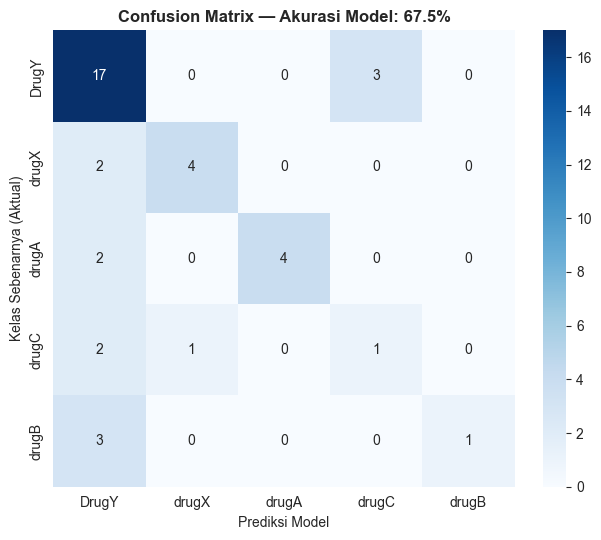

In [43]:
import numpy as np

kelas_urut3 = model['kelas_list']
cm_array = np.array([[cm[ya][yp] for yp in kelas_urut3] for ya in kelas_urut3])

plt.figure(figsize=(6.5, 5.5))
ax = sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues',
                  xticklabels=kelas_urut3, yticklabels=kelas_urut3, cbar=True)
ax.set_title(f'Confusion Matrix — Akurasi Model: {akurasi:.1%}', fontsize=12, fontweight='bold')
ax.set_xlabel('Prediksi Model')
ax.set_ylabel('Kelas Sebenarnya (Aktual)')
plt.tight_layout()
plt.show()


**Cara membaca confusion matrix ini (untuk orang awam):** setiap baris adalah obat yang *sebenarnya* diberikan ke pasien, setiap kolom adalah obat hasil *tebakan* model. Kotak di garis diagonal (dari kiri-atas ke kanan-bawah) adalah tebakan yang **benar**. Semakin banyak angka besar berada di luar diagonal, semakin sering model salah menebak.

## 5. Ringkasan Hasil

- Model Naive Bayes kategorikal berhasil diimplementasikan sepenuhnya dari nol (prior, tabel kontingensi,
  likelihood dengan Laplace smoothing, posterior, dan keputusan argmax) tanpa memakai library machine learning.
- Hasil perhitungan manual pada bagian Simulasi Kasus **konsisten** dengan hasil fungsi `naive_bayes_predict` pada
  bagian Implementasi untuk query yang sama, yang membuktikan implementasi program sudah benar.
- Akurasi model pada data uji ditampilkan pada Langkah D di atas (bergantung pada pembagian data acak yang
  digunakan).

> Silakan sesuaikan bagian *query* pada Langkah 3 (Simulasi Kasus) dengan kasus spesifik yang diberikan pada
> link Google Drive kelompok tugas besar apabila kasus tersebut berbeda dari contoh baris data yang dipakai di sini.


## 6. DAFTAR PUSTAKA

1. Hardianti, "Penerapan Metode Naïve Bayes pada Klasifikasi Judul Jurnal," *Prosiding SAKTI (Seminar Ilmu Komputer dan Teknologi Informasi)*, Universitas Mulawarman, 2018.
2. "Klasifikasi Menggunakan Metode Naive Bayes untuk Menentukan Calon Penerima PIP," *JATI (Jurnal Mahasiswa Teknik Informatika)*, Institut Teknologi Nasional Malang, 2020.
3. Hartono, "Penerapan Metode Naïve Bayes Classifier untuk Klasifikasi Judul Berita," *Jurnal SimanteC*, Universitas Trunojoyo Madura, vol. 12, 2023.
4. F. Lesmana, A. D. Rizkimu, M. R. Nurrulloh, M. F. Fathurrahman, dan A. H. Hasibuan, "Analisis Kinerja Algoritma Naive Bayes dalam Klasifikasi Cuaca Menggunakan Dataset Play Tennis," *Journal of Information Technology and Informatics Engineering (JITIE)*, vol. 1, no. 1, 2025.
5. "Analisis Algoritma Naive Bayes Classifier (NBC) pada Klasifikasi Tingkat Minat Barang," *JATI (Jurnal Mahasiswa Teknik Informatika)*, Institut Teknologi Nasional Malang, vol. 7, no. 1, Februari 2023.
6. "Implementasi Algoritma Naive Bayes pada Data Set Kualitatif Prediksi Kebangkrutan," *JURIKOM (Jurnal Riset Komputer)*, vol. 7, no. 1, Februari 2020.
7. B. Indraja dan K. Annapurani, "Classification of Medicines using Naive Bayes Classifier," *Research Journal of Pharmacy and Technology*, vol. 11, no. 5, pp. 1940–1944, 2018.
8. "Machine Learning Models for Classification Tasks Related to Drug Safety," *Molecular Diversity*, Springer, 2021.
9. "AI-Based Smart Prediction of Clinical Disease Using Random Forest Classifier and Naive Bayes," *The Journal of Supercomputing*, Springer, 2020.
10. "A Naive Bayes Classifier for Prediction of Multidrug Resistance Reversal Activity on the Basis of Atom Typing," *Journal of Medicinal Chemistry*, American Chemical Society, 2005.

*(Referensi buku dan tautan web materi perkuliahan LMS tidak dihitung dalam 10 jurnal di atas, sesuai instruksi tugas.)*
